# Métricas de Clasificación Multiclase con PyTorch
## Dataset: Meningitis with Missing Values

En este laboratorio aplicamos un modelo de **clasificación multiclase** con PyTorch
para predecir el tipo de infección de meningitis:
- **Viral** (565 casos)
- **Bacterial** (499 casos)
- **Unknown** (124 casos)

Y calculamos todas las métricas de clasificación:
**Accuracy, Matriz de Confusión, Precision, Recall, F1-Score y Curva ROC**.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              roc_curve, roc_auc_score)

# Verificar GPU
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

False
Usando: cpu


## 1. Descripción del Dataset

El dataset contiene registros clínicos de **1,200 pacientes** con meningitis,
con variables como edad, conteo de glóbulos blancos, nivel de proteína, glucosa,
hemoglobina, nivel de CRP y otras.

**Variable objetivo:** `Diagnosis` — el tipo de infección:
- **Viral**: 565 casos (48%)
- **Bacterial**: 499 casos (42%)
- **Unknown**: 124 casos (10%)

A diferencia de clasificación binaria (0 o 1), aquí hay **3 clases posibles**,
lo que requiere `CrossEntropyLoss` en lugar de `BCELoss` y `LabelEncoder`
para convertir los textos a números (0, 1, 2).

In [5]:
#  CARGAR
ruta = r'/content/drive/MyDrive/machine learning/datsets/mening missing 12.csv'
df = pd.read_csv(ruta)

print("Shape original:", df.shape)
print()
print("Variable objetivo - Diagnosis (tipo de infección):")
print(df['Diagnosis'].value_counts(dropna=False))
print()
print("Nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape original: (1200, 14)

Variable objetivo - Diagnosis (tipo de infección):
Diagnosis
Viral        565
Bacterial    499
Unknown      124
NaN           12
Name: count, dtype: int64

Nulos por columna:
Age                  7
Gender               9
WBC_Count            8
Protein_Level       10
Glucose_Level        8
Pathogen_Present     8
Diagnosis           12
Outcome             10
Hemoglobin          19
WBC_Blood_Count     10
Platelets           12
CRP_Level           13
dtype: int64


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Preparación del Dataset

In [7]:
#  ELIMINAR COLUMNA IDENTIFICADORA
# Patient_ID es solo un número de registro, no aporta información predictiva
df = df.drop(columns=['Patient_ID'])

# ELIMINAR FILAS SIN DIAGNOSIS (no podemos entrenar sin la respuesta)
df = df.dropna(subset=['Diagnosis'])
print(f"Filas después de eliminar NaN en Diagnosis: {len(df)}")

# ELIMINAR COLUMNAS CON >50% DE NaN
umbral = 0.5 * len(df)
cols_muchos_nulos = df.columns[df.isnull().sum() > umbral].tolist()
if cols_muchos_nulos:
    df = df.drop(columns=cols_muchos_nulos)
    print(f"Columnas eliminadas por >50% NaN: {cols_muchos_nulos}")
else:
    print("Ninguna columna superó el 50% de nulos")

# IMPUTAR NaN RESTANTES
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"  {col}: NaN imputados con mediana")

for col in df.select_dtypes(include='object').columns:
    if col == 'Diagnosis': continue
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f"  {col}: NaN imputados con moda")

print(f"\nNaN restantes: {df.isnull().sum().sum()}")

Filas después de eliminar NaN en Diagnosis: 1188
Ninguna columna superó el 50% de nulos
  Age: NaN imputados con mediana
  WBC_Count: NaN imputados con mediana
  Protein_Level: NaN imputados con mediana
  Glucose_Level: NaN imputados con mediana
  Hemoglobin: NaN imputados con mediana
  WBC_Blood_Count: NaN imputados con mediana
  Platelets: NaN imputados con mediana
  CRP_Level: NaN imputados con mediana
  Gender: NaN imputados con moda
  Pathogen_Present: NaN imputados con moda
  Outcome: NaN imputados con moda

NaN restantes: 0


In [8]:
#  LABELENCODER: convierte texto a números
# Bacterial → 0  |  Unknown → 1  |  Viral → 2  (orden alfabético)
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

print("Clases encontradas:")
for i, clase in enumerate(le.classes_):
    print(f"  {i} → {clase}: {(df['Diagnosis']==i).sum()} casos")

# ── ONE-HOT ENCODING para columnas de texto restantes ────────────────────────
# Outcome, Gender, Pathogen_Present, Risk_Level son texto → los convertimos
cols_cat = df.select_dtypes(include='object').columns.tolist()
print(f"\nColumnas de texto a convertir: {cols_cat}")
df = pd.get_dummies(df, columns=cols_cat)
print(f"Shape después de one-hot encoding: {df.shape}")

# Mover Diagnosis al final
cols = [c for c in df.columns if c != 'Diagnosis'] + ['Diagnosis']
df = df[cols]
print(f"\nDataset final: {df.shape[0]} filas, {df.shape[1]} columnas")

Clases encontradas:
  0 → Bacterial: 499 casos
  1 → Unknown: 124 casos
  2 → Viral: 565 casos

Columnas de texto a convertir: ['Gender', 'Pathogen_Present', 'Outcome', 'Risk_Level']
Shape después de one-hot encoding: (1188, 18)

Dataset final: 1188 filas, 18 columnas


## 3. Split, Normalización y Tensores

Usamos `stratify=y` para garantizar que las 3 clases estén
proporcionalmente representadas tanto en entrenamiento como en prueba.

**Diferencia clave con clasificación binaria:**
`y_train_t` usa `dtype=torch.long` (entero) en lugar de `torch.float32`,
porque `CrossEntropyLoss` lo requiere así.

In [9]:
#  SPLIT Y NORMALIZACIÓN
X = df.drop('Diagnosis', axis=1).astype(float).values
y = df['Diagnosis'].values

X_train_arr, X_test, y_train_arr, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización Z-score
X_mean = X_train_arr.mean(axis=0)
X_std  = X_train_arr.std(axis=0)
X_std[X_std == 0] = 1  # evitar división por cero

X_train_arr = (X_train_arr - X_mean) / X_std
X_test       = (X_test - X_mean) / X_std

# Convertir a tensores
# IMPORTANTE: y usa torch.long (no float) porque CrossEntropyLoss lo requiere
X_train_t = torch.from_numpy(X_train_arr).float().to(device)
y_train_t = torch.from_numpy(y_train_arr).long().to(device)  # ← long para multiclase

print(f"Entrenamiento: {len(X_train_t)} filas")
print(f"Prueba:        {len(X_test)} filas")
print(f"Variables de entrada: {X_train_arr.shape[1]}")
print()
print("Distribución en prueba:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase}: {(y_test==i).sum()} casos")

Entrenamiento: 950 filas
Prueba:        238 filas
Variables de entrada: 17

Distribución en prueba:
  Bacterial: 100 casos
  Unknown: 25 casos
  Viral: 113 casos


In [10]:
# ── DATALOADER
dataloader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
print(f"Batches por epoch: {len(dataloader)}")

Batches por epoch: 15


## 4. Modelo PyTorch

**Diferencias clave respecto a clasificación binaria:**
- `D_out = 3` en lugar de 1 (una salida por cada clase)
- **NO hay `Sigmoid`** al final — `CrossEntropyLoss` incluye `Softmax` internamente
- **`CrossEntropyLoss`** en lugar de `BCELoss`
- En la evaluación usamos `torch.argmax` para tomar la clase con mayor probabilidad

In [11]:
#  MODELO
D_in  = X_train_arr.shape[1]
H     = 64
D_out = 3   # ← 3 clases: Bacterial, Unknown, Viral

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),   # capa oculta: entradas → 64 neuronas
    torch.nn.ReLU(),             # activación
    torch.nn.Linear(H, D_out)   # salida: 64 → 3 (sin Sigmoid — CrossEntropy lo maneja)
).to(device)

# CrossEntropyLoss = función de pérdida para clasificación multiclase
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(model)

Sequential(
  (0): Linear(in_features=17, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=3, bias=True)
)


## 5. Entrenamiento

In [12]:
#  ENTRENAMIENTO
epochs   = 100
log_each = 10
l        = []

model.train()
for e in range(1, epochs + 1):

    _l = []
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        y_pred = model(x_b)            # forward
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()          # limpiar gradientes
        loss.backward()                # backprop (autograd)
        optimizer.step()               # actualizar pesos

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs}  Loss {np.mean(l):.4f}")
        torch.save(model.state_dict(), f"./checkpoint_mening_multi_{e}.pt")

Epoch 10/100  Loss 0.4653
Epoch 20/100  Loss 0.4163
Epoch 30/100  Loss 0.3924
Epoch 40/100  Loss 0.3760
Epoch 50/100  Loss 0.3630
Epoch 60/100  Loss 0.3521
Epoch 70/100  Loss 0.3426
Epoch 80/100  Loss 0.3342
Epoch 90/100  Loss 0.3265
Epoch 100/100  Loss 0.3194


## 6. Métricas de Clasificación

En multiclase las métricas se calculan igual que en binaria,
pero se promedian sobre las 3 clases. Usamos `average='weighted'`
para que las clases con más ejemplos (Viral y Bacterial) pesen más.

In [13]:
# ── PREDICCIONES
model.eval()
with torch.no_grad():
    # El modelo produce 3 valores por fila (uno por clase)
    y_logits = model(torch.from_numpy(X_test).float().to(device))

# En multiclase tomamos la clase con el valor más alto (argmax)
# En binaria usábamos >= 0.5, aquí usamos argmax
y_pred_clases = torch.argmax(y_logits, dim=1).cpu().numpy()

# Para la curva ROC necesitamos probabilidades → aplicamos softmax
y_prob = torch.softmax(y_logits, dim=1).cpu().numpy()

print("Primeras 5 predicciones:")
for i in range(5):
    pred_clase = le.classes_[y_pred_clases[i]]
    real_clase = le.classes_[y_test[i]]
    correcto = "✅" if y_pred_clases[i] == y_test[i] else "❌"
    print(f"  Real: {real_clase:10s} | Predicho: {pred_clase:10s} {correcto}")

Primeras 5 predicciones:
  Real: Unknown    | Predicho: Unknown    ✅
  Real: Bacterial  | Predicho: Bacterial  ✅
  Real: Unknown    | Predicho: Bacterial  ❌
  Real: Bacterial  | Predicho: Bacterial  ✅
  Real: Bacterial  | Predicho: Bacterial  ✅


### 6.1 Accuracy

 El Accuracy mide la proporción de predicciones correctas sobre el total de predicciones. Es una métrica global que nos da una idea general de qué tan bien el modelo clasifica las instancias en todas las clases. Sin embargo, puede ser engañosa en datasets desbalanceados, donde una clase es mucho más frecuente que otras.

In [14]:
# ── ACCURACY ─────────────────────────────────────────────────────────────────
accuracy = accuracy_score(y_test, y_pred_clases)
print(f"Accuracy en test: {accuracy*100:.2f}%")
print()
# Baseline: si siempre predijéramos la clase más frecuente (Viral ~48%)
baseline = max([(y_test==i).sum()/len(y_test) for i in range(3)])
print(f"Baseline (siempre predecir clase más frecuente): {baseline*100:.1f}%")
print(f"Nuestro modelo: {accuracy*100:.2f}%")
print(f"¿Mejora el baseline? {'Sí ✅' if accuracy > baseline else 'No — revisar modelo'}")

Accuracy en test: 76.47%

Baseline (siempre predecir clase más frecuente): 47.5%
Nuestro modelo: 76.47%
¿Mejora el baseline? Sí ✅


### 6.2 Matriz de Confusión

 La Matriz de Confusión es una tabla que permite visualizar el rendimiento de un algoritmo de clasificación. Muestra cuántas instancias de cada clase fueron clasificadas correctamente (verdaderos positivos/negativos) y cuántas fueron clasificadas incorrectamente (falsos positivos/negativos). En un problema multiclase, nos ayuda a entender dónde el modelo se está equivocando, por ejemplo, confundiendo la clase 'Unknown' con 'Bacterial' o 'Viral'.

En multiclase la matriz es 3x3 — una fila y columna por cada clase.
Fila = lo que era real | Columna = lo que predijo el modelo.
Los números en la diagonal son los aciertos.

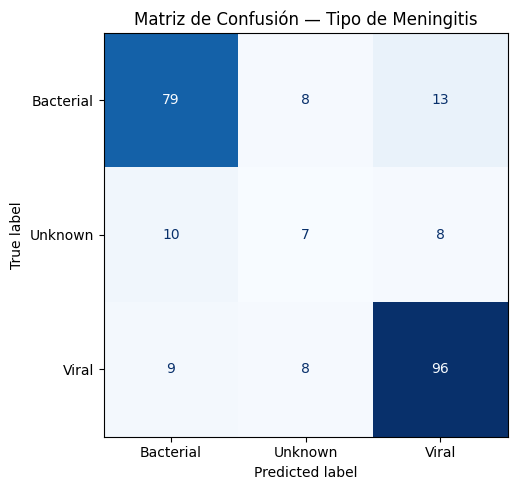

Interpretación de la diagonal (aciertos):
  Bacterial : 79/100 aciertos (79.0%)
  Unknown   : 7/25 aciertos (28.0%)
  Viral     : 96/113 aciertos (85.0%)


In [15]:
# ── MATRIZ DE CONFUSIÓN ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_clases)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=plt.gca(), colorbar=False, cmap='Blues')
plt.title("Matriz de Confusión — Tipo de Meningitis")
plt.tight_layout()
plt.show()

print("Interpretación de la diagonal (aciertos):")
for i, clase in enumerate(le.classes_):
    total_real = cm[i].sum()
    aciertos   = cm[i][i]
    print(f"  {clase:10s}: {aciertos}/{total_real} aciertos ({aciertos/total_real*100:.1f}%)")

### 6.3 Precision, Recall y F1-Score por clase

 Estas métricas son cruciales, especialmente en problemas con clases desbalanceadas, ya que ofrecen una visión más detallada que el Accuracy.
- **Precision:** Responde a la pregunta: "De todas las veces que el modelo predijo esta clase, ¿cuántas fueron correctas?" Es importante cuando el costo de un falso positivo es alto.
- **Recall (Sensibilidad):** Responde a la pregunta: "De todas las instancias que *realmente* pertenecen a esta clase, ¿cuántas logró identificar el modelo?" Es importante cuando el costo de un falso negativo es alto.
- **F1-Score:** Es la media armónica de Precision y Recall. Proporciona un equilibrio entre ambas métricas, siendo útil cuando no se quiere favorecer a una sobre la otra y se busca un modelo robusto.

En multiclase las métricas se calculan igual que en binaria, pero se promedian sobre las 3 clases. Usamos `average='weighted'` para que las clases con más ejemplos (Viral y Bacterial) pesen más.

In [16]:
# ── PRECISION, RECALL Y F1 POR CLASE ─────────────────────────────────────────
# average='weighted' pondera por la cantidad de casos de cada clase
precision_w = precision_score(y_test, y_pred_clases, average='weighted')
recall_w    = recall_score(y_test, y_pred_clases, average='weighted')
f1_w        = f1_score(y_test, y_pred_clases, average='weighted')

print("=== MÉTRICAS GLOBALES (weighted) ===")
print(f"  Precision : {precision_w:.4f} ({precision_w*100:.2f}%)")
print(f"  Recall    : {recall_w:.4f} ({recall_w*100:.2f}%)")
print(f"  F1-Score  : {f1_w:.4f} ({f1_w*100:.2f}%)")

print()
print("=== MÉTRICAS POR CLASE ===")
precision_c = precision_score(y_test, y_pred_clases, average=None)
recall_c    = recall_score(y_test, y_pred_clases, average=None)
f1_c        = f1_score(y_test, y_pred_clases, average=None)

print(f"{'Clase':12s} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
print("-" * 52)
for i, clase in enumerate(le.classes_):
    print(f"{clase:12s} | {precision_c[i]:>10.4f} | {recall_c[i]:>10.4f} | {f1_c[i]:>10.4f}")

=== MÉTRICAS GLOBALES (weighted) ===
  Precision : 0.7602 (76.02%)
  Recall    : 0.7647 (76.47%)
  F1-Score  : 0.7623 (76.23%)

=== MÉTRICAS POR CLASE ===
Clase        |  Precision |     Recall |   F1-Score
----------------------------------------------------
Bacterial    |     0.8061 |     0.7900 |     0.7980
Unknown      |     0.3043 |     0.2800 |     0.2917
Viral        |     0.8205 |     0.8496 |     0.8348


### 6.4 F1-Score — Cálculo manual para entender la fórmula

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [17]:
# ── F1 MANUAL POR CLASE ──────────────────────────────────────────────────────
print("Verificación manual del F1-Score por clase:")
for i, clase in enumerate(le.classes_):
    p = precision_c[i]
    r = recall_c[i]
    if p + r > 0:
        f1_manual = 2 * (p * r) / (p + r)
        print(f"  {clase}: 2 × ({p:.4f} × {r:.4f}) / ({p:.4f} + {r:.4f}) = {f1_manual:.4f}")

Verificación manual del F1-Score por clase:
  Bacterial: 2 × (0.8061 × 0.7900) / (0.8061 + 0.7900) = 0.7980
  Unknown: 2 × (0.3043 × 0.2800) / (0.3043 + 0.2800) = 0.2917
  Viral: 2 × (0.8205 × 0.8496) / (0.8205 + 0.8496) = 0.8348


### 6.5 Curva ROC y AUC — One vs Rest

 La Curva ROC (Receiver Operating Characteristic) y el Área Bajo la Curva (AUC) son métricas para evaluar el rendimiento de un clasificador. La curva ROC muestra la relación entre la Tasa de Verdaderos Positivos (TPR o Recall) y la Tasa de Falsos Positivos (FPR) en diferentes umbrales de clasificación. El AUC resume esta curva en un solo valor; un AUC de 1.0 indica un clasificador perfecto, mientras que un AUC de 0.5 indica un clasificador que no es mejor que adivinar al azar. Un AUC alto significa que el modelo es bueno discriminando entre clases.

En multiclase la curva ROC se calcula con la estrategia **One vs Rest**:
por cada clase se calcula una curva ROC tratando esa clase como positiva
y todas las demás como negativas.

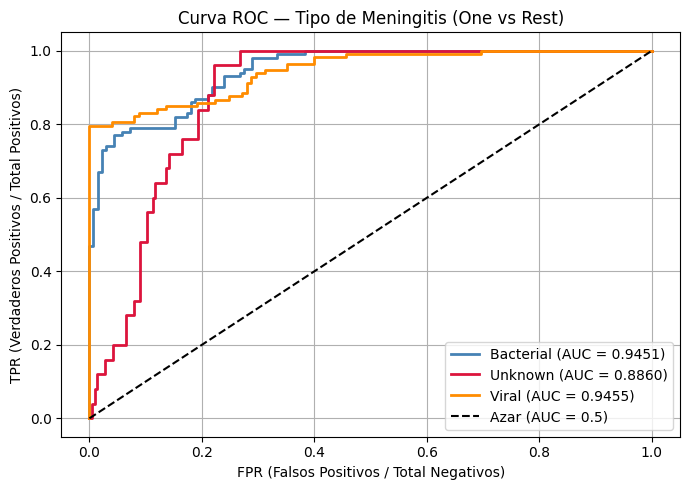

AUC por clase:
  Bacterial : 0.9451
  Unknown   : 0.8860
  Viral     : 0.9455
  AUC promedio: 0.9255


In [18]:
# ── CURVA ROC MULTICLASE (One vs Rest)
colores = ['steelblue', 'crimson', 'darkorange']

plt.figure(figsize=(7, 5))

aucs = []
for i, clase in enumerate(le.classes_):
    # Para cada clase: 1 si es esa clase, 0 si es cualquier otra
    y_test_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, i])
    auc = roc_auc_score(y_test_bin, y_prob[:, i])
    aucs.append(auc)
    plt.plot(fpr, tpr, linewidth=2, color=colores[i], label=f'{clase} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
plt.xlabel('FPR (Falsos Positivos / Total Negativos)')
plt.ylabel('TPR (Verdaderos Positivos / Total Positivos)')
plt.title('Curva ROC — Tipo de Meningitis (One vs Rest)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("AUC por clase:")
for i, clase in enumerate(le.classes_):
    print(f"  {clase:10s}: {aucs[i]:.4f}")
print(f"  AUC promedio: {np.mean(aucs):.4f}")

## 7. Resumen completo y gráficas finales

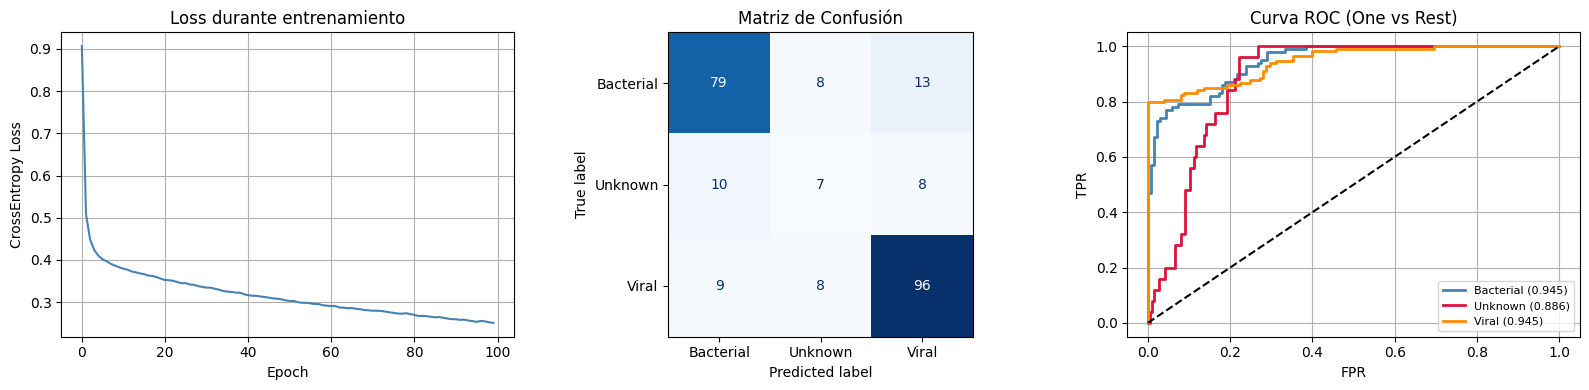

In [19]:
# GRÁFICAS FINALES
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Curva de loss
axes[0].plot(l, color='steelblue')
axes[0].set_title("Loss durante entrenamiento")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CrossEntropy Loss")
axes[0].grid(True)

# Matriz de confusión
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Matriz de Confusión")

# Curva ROC
for i, clase in enumerate(le.classes_):
    y_test_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, i])
    auc = roc_auc_score(y_test_bin, y_prob[:, i])
    axes[2].plot(fpr, tpr, linewidth=2, color=colores[i], label=f'{clase} ({auc:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('Curva ROC (One vs Rest)')
axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.show()

In [20]:
# ── RESUMEN FINAL ────────────────────────────────────────────────────────────
print("=" * 50)
print("  RESUMEN DE MÉTRICAS — MENINGITIS MULTICLASE")
print("=" * 50)
print(f"  Clases:    {list(le.classes_)}")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_clases)*100:.2f}%")
print(f"  Precision  : {precision_score(y_test, y_pred_clases, average='weighted')*100:.2f}% (weighted)")
print(f"  Recall     : {recall_score(y_test, y_pred_clases, average='weighted')*100:.2f}% (weighted)")
print(f"  F1-Score   : {f1_score(y_test, y_pred_clases, average='weighted')*100:.2f}% (weighted)")
print(f"  AUC promedio: {np.mean(aucs):.4f}")
print("=" * 50)
print()
print("Métricas por clase:")
print(f"  {'Clase':12s} | {'Precision':>10} | {'Recall':>10} | {'F1':>10} | {'AUC':>8}")
print("  " + "-" * 58)
for i, clase in enumerate(le.classes_):
    print(f"  {clase:12s} | {precision_c[i]:>10.4f} | {recall_c[i]:>10.4f} | {f1_c[i]:>10.4f} | {aucs[i]:>8.4f}")

torch.save(model.state_dict(), './checkpoint_mening_multiclase_final.pt')
print("\nModelo guardado como 'checkpoint_mening_multiclase_final.pt' ✅")

  RESUMEN DE MÉTRICAS — MENINGITIS MULTICLASE
  Clases:    ['Bacterial', 'Unknown', 'Viral']
  Accuracy   : 76.47%
  Precision  : 76.02% (weighted)
  Recall     : 76.47% (weighted)
  F1-Score   : 76.23% (weighted)
  AUC promedio: 0.9255

Métricas por clase:
  Clase        |  Precision |     Recall |         F1 |      AUC
  ----------------------------------------------------------
  Bacterial    |     0.8061 |     0.7900 |     0.7980 |   0.9451
  Unknown      |     0.3043 |     0.2800 |     0.2917 |   0.8860
  Viral        |     0.8205 |     0.8496 |     0.8348 |   0.9455

Modelo guardado como 'checkpoint_mening_multiclase_final.pt' ✅


## Conclusiones

- El problema es **multiclase** (3 clases) a diferencia de los laboratorios
  anteriores que eran binarios. Los cambios clave en el código son:
  `CrossEntropyLoss`, `D_out=3`, `torch.long` y `torch.argmax`.
- La **Matriz de Confusión** es ahora 3×3 — muestra cómo se confunden entre sí
  las tres clases. Los números de la diagonal son los aciertos.
- Para la curva **ROC en multiclase** se usa la estrategia **One vs Rest**:
  se calcula una curva por cada clase tratándola como positiva y las demás como negativas.
- El **AUC promedio** resume en un número qué tan bien separa el modelo las 3 clases.
  Un valor por encima de 0.5 indica que el modelo es mejor que adivinar al azar.